# Regridding NetCDF files to a reference grid for model comparison

This script regrids `.nc` files with spatial `x`, `y`, `lon(x, y)`, and `lat(x, y)` coordinates onto a reference grid. This is necessary to compare data from different models on a common grid.

The following libraries and functions are required to run this script.

In [1]:
#Import libraries:

import xarray as xr #Read and work with netCDF files
import numpy as np #Work with arrays and perform numerical operations
import matplotlib.pyplot as plt #Create plots and visualizations
import cartopy.crs as ccrs #Work with cartographic projections and create maps
from scipy.interpolate import griddata # Interpolate data points onto a new grid
import requests #Make HTTP requests to access data from the I4C API
import sys
sys.path.append("..")# Allow the script to import files located one directory level above the current file
from utils.interpolation import Interpolator # Import the Interpolator class used for regridding
from utils.DestinyGridParameters import newlonlat_city  # Import the function that defines the target grid for each city

#interpolation.py was downloaded from 'https://github.com/ecmwf-projects/c3s-atlas/blob/main/c3s_atlas/interpolation.py'
import os # Work with folders and file paths

### Definition of global variables:

In this cell, the file name, the data version, the data path, the output path and the city name are defined. Information such as the variable name, domain, reanalysis, simulation type, model, time interval, and time period is also extracted from the file name. These values will be used later in the script.

In [2]:
#Data path and file name:

file= 'tas_ALPX-3f_ERA5_evaluation_r1i1p1f1_BCCR-UCAN_WRF451R-CI4C_v1-r1_1hr_199901010000-199912312300.nc'
variable, domain, reanalisis, simulation_type, run_type1, runing_centre, model, run_type2, time_interval, time_period = file.split("_")
data_version = 'v20240710'

# path = '../utils/'#test path
path = '../I4C_CPRCM_DATA'+'/'+domain+'/'+runing_centre+'/'+reanalisis+'/'+simulation_type+'/'+run_type1+'/'+model+'/'+run_type2+'/'+time_interval+'/'+variable+'/'+data_version+'/'
path_save = '../I4C_CPRCM_CITY_DATA'+'/'+domain+'/'+runing_centre+'/'+reanalisis+'/'+simulation_type+'/'+run_type1+'/'+model+'/'+run_type2+'/'+time_interval+'/'+variable+'/'+data_version+'/'

path_file = path+file

#City name
city_name='Paris'

### Rest of the code

In the cell below, a function defined in the utils folder is used to obtain the target grid for the selected city. This function returns the target longitude and latitude coordinates (new_longitude, new_latitude) and several grid parameters: the first and last x values, the number of points in the x and y directions, the grid spacing in the x and y directions, and the first and last y values.

This information is based on the grid parameters defined for each city in the I4C GitHub repository: ''https://github.com/ecmwf-projects/c3s-atlas/blob/main/c3s_atlas/interpolation.py

Then, the NetCDF file is opened and cropped to a domain that is one degree larger than the reference domain. This one-degree buffer is added to avoid losing boundary points during the interpolation. After interpolation, the result will be cropped back to the desired domain.

Finally, the original longitude and latitude coordinates of the cropped dataset are extracted.

In [3]:
#Calculate the I4C grid for the city according the GitHub repository and save the grid parameters:
new_longitude, new_latitude, x_first, xend, x_size, y_size, x_increment, y_increment, y_first, yend = newlonlat_city(city_name)
#New_longitude and new_latitude already have the limits expanded

#Read the file and extract the variable :
ds = xr.open_dataset(path_file)
# T = ds[variable]

#Crop the dataset to the city area using the grid parameters obtained from the GitHub repository:
#It was ampliated the range 1º in each side to not lose data points in the interpolation below
city = ds.where((ds.lon >= (x_first-1)) & (ds.lon <= (xend+1)) &(ds.lat >= (y_first-1)) & (ds.lat <= (yend+1)),drop=True)

##Change coordinates from the model to the I4C grid:

#Original coordinates
lon_old = city["lon"].values
lat_old = city["lat"].values



{'gridtype': 'lonlat', 'xsize': 89, 'ysize': 59, 'xfirst': 0.828125, 'xinc': 0.03125, 'yfirst': 47.921875, 'yinc': 0.03125}
(152,) (122,)


A bilinear interpolation is performed in the cell below. Other interpolation methods can be used by changing the value of "interpolation_method" in int_attr, for example to "nearest_s2d", "patch", "conservative", or "conservative_normed"

In [4]:

# prepare a dictionary for Interpolator class with the interpolation parameters:
int_attr = {
    # "interpolation_method": "conservative", #Regrid method
    "interpolation_method": "bilinear",
    "lats": new_latitude,
    "lons": new_longitude,
    "var_name": variable #Indicates the name of the variable to be interpolated.
}
#Create an object with the necesary information to interpolate
interpolator = Interpolator(int_attr)
#Perform the interpolation
# city_interp = interpolator(city)
city_interp_0 = interpolator(city)

/nfs/home/gmeteo/moralesi/prueba_servidor/Y/envs/netcdf/lib/python3.14/site-packages/xesmf/smm.py:197: RuntimeWarning: invalid value encountered in cast
  outdata = outdata.astype(indata_dtype)


Since an additional one-degree margin was used during interpolation, the interpolated dataset is cropped here to keep only the target city domain.

In [5]:
#Crop to the extra degree:
city_interp = city_interp_0.where((city_interp_0.lon >= x_first) & (city_interp_0.lon <= xend) &(city_interp_0.lat >= y_first) & (city_interp_0.lat <= yend),drop=True)

The next three cells show the original data, the data after the first crop with a one-degree buffer around the boundaries, and the final result after interpolation. In the first and second figures, the grid is not regular, while in the final interpolated result it is regular.

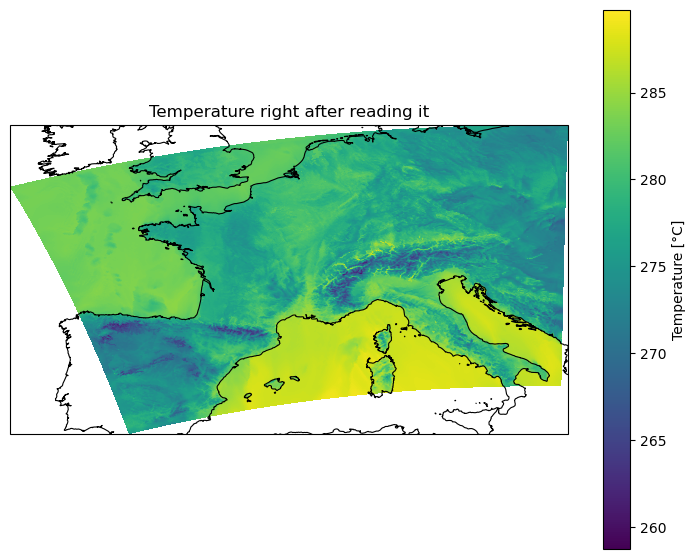

In [6]:
##Data right after reading it:

#Read the variable you want to visualize and select the first time to be able to represent it in a 2D map:
T = ds[variable].isel(time=0)

# Visualize the data with the silhouette of the continents using cartopy
fig = plt.figure(figsize=(9, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
m = ax.pcolormesh(ds["lon"],ds["lat"],T,shading="auto",transform=ccrs.PlateCarree())
ax.coastlines(resolution="10m", linewidth=0.8)
plt.colorbar(m, ax=ax, label="Temperature [°C]")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Temperature right after reading it")
plt.show()

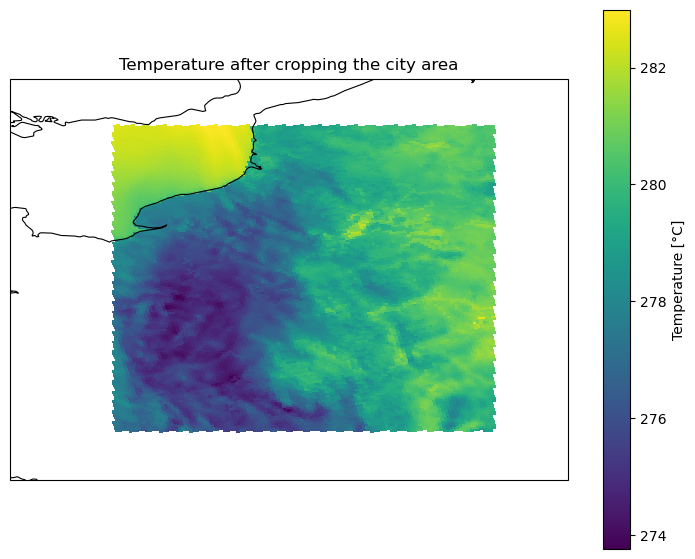

In [7]:
##Data after cropping the city area:

#Read the variable you want to visualize and select the first time to be able to represent it in a 2D map:
T2 = city[variable].isel(time=0)

# Visualize the data with the silhouette of the continents using cartopy
fig = plt.figure(figsize=(9, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
m = ax.pcolormesh(city["lon"],city["lat"],T2,shading="auto",transform=ccrs.PlateCarree())
ax.coastlines(resolution="10m", linewidth=0.8)
plt.colorbar(m, ax=ax, label="Temperature [°C]")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Temperature after cropping the city area")
plt.show()

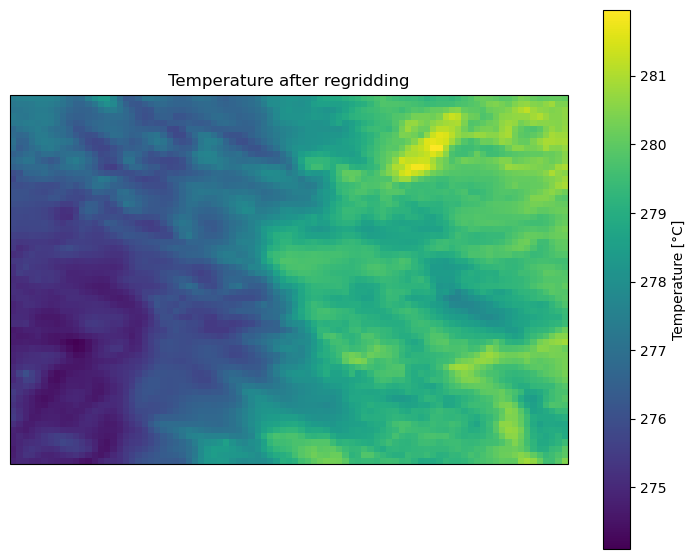

In [8]:
##Data after regridding with conservative normed method:

#Read the variable you want to visualize and select the first time to be able to represent it in a 2D map:
T3= city_interp[variable].isel(time=0)

# Visualize the data with the silhouette of the continents using cartopy
fig = plt.figure(figsize=(9, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
m = ax.pcolormesh(city_interp["lon"],city_interp["lat"],T3,shading="auto",transform=ccrs.PlateCarree())
ax.coastlines(resolution="10m", linewidth=0.8)
plt.colorbar(m, ax=ax, label="Temperature [°C]")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Temperature after regridding")
plt.show()

Here, it's saved the new file in the directory defined in the global variables cell.

In [9]:
#Create a directory to save the results of the interpolation:
os.makedirs(path_save, exist_ok = True)

#Save the cropped and interpolated dataset (city_interp) as a new netCDF file in the above directory:
base_name = file.split(".")[0]#It takes the file name without the extension
city_interp.to_netcdf(path_save+"/"+base_name+'_'+city_name+"_cropped_interpolated"+'.nc')